In [42]:
#import necessary library
import numpy as np
import pandas as pd

In [43]:
#import dataset
south = pd.read_csv("southern_africa.csv")
print(south.head())

        country country_code  \
0  South Africa          ZAF   
1  South Africa          ZAF   
2  South Africa          ZAF   
3  South Africa          ZAF   
4  South Africa          ZAF   

                                           indicator     indicator_code  \
0                            GDP (constant 2015 US$)     NY.GDP.MKTP.KD   
1                 Inflation, GDP deflator (annual %)  NY.GDP.DEFL.KD.ZG   
2              School enrollment, tertiary (% gross)        SE.TER.ENRR   
3  Unemployment, total (% of total labor force) (...  SL.UEM.TOTL.NE.ZS   
4            Life expectancy at birth, total (years)     SP.DYN.LE00.IN   

          2000         2001         2002         2003         2004  \
0  2.21692E+11  2.27678E+11  2.36103E+11  2.43065E+11  2.54136E+11   
1  9.182191416  7.800474963  12.53795791  6.395763587   6.04217159   
2           ..           ..           ..           ..           ..   
3        29.88        25.37        27.18        27.12        24.67   
4     

In [44]:
#rename indicator value for proper callup and easy selection
print(south["indicator"].unique())

south["indicator"] = south["indicator"].replace({'GDP (constant 2015 US$)':'GDP', 
                                                 'Inflation, GDP deflator (annual %)':'inflation',
                                                 'School enrollment, tertiary (% gross)':'sch_enrol',
                                                 'Unemployment, total (% of total labor force) (national estimate)':'unemployment',
                                                 'Life expectancy at birth, total (years)':'life_expectancy',
                                                 'Poverty headcount ratio at national poverty lines (% of population)':'poverty_head',
                                                 'Population, total':'population', 
                                                 'Foreign direct investment, net inflows (% of GDP)':'fdi'})
print(south["indicator"].unique())

['GDP (constant 2015 US$)' 'Inflation, GDP deflator (annual %)'
 'School enrollment, tertiary (% gross)'
 'Unemployment, total (% of total labor force) (national estimate)'
 'Life expectancy at birth, total (years)'
 'Poverty headcount ratio at national poverty lines (% of population)'
 'Population, total' 'Foreign direct investment, net inflows (% of GDP)'
 nan]
['GDP' 'inflation' 'sch_enrol' 'unemployment' 'life_expectancy'
 'poverty_head' 'population' 'fdi' nan]


In [45]:
#check dataset shape for extra row or column
print(south.shape)

(133, 29)


In [46]:
#Extra row is detected, there's a need to drop or delete them.
south = south.iloc[:-5, :]
print(south.shape)

(128, 29)


In [47]:
#set the first four column as index
south.set_index(["country", "country_code", "indicator", "indicator_code"], inplace=True)

In [48]:
#Check for missing value
print(south.isna().sum().sum())

0


In [49]:
#Dataset shows no missing value because the empty cells in the dataset does occur as empty to python, 
#Convert every empty cell to a recognizable empty cell

south = south.replace(['NA', 'N/A', 'na', 'null', '-', '?', ' ', '..'], np.nan)
print(south.isna().sum().sum())

776


In [50]:
#fill missing values with forward and backward filling because the data is a timeseries data

#def a function for forwqrd and backward filling
def for_back_fill_rowwise(df):
    df = df.ffill(axis=1).bfill(axis=1)

    return df

In [51]:
south = for_back_fill_rowwise(south)
print(south.isna().sum().sum())

0


In [52]:
#check data type and info
print(type(south))
print(south.info())

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 128 entries, ('South Africa', 'ZAF', 'GDP', 'NY.GDP.MKTP.KD') to ('Comoros', 'COM', 'fdi', 'BX.KLT.DINV.WD.GD.ZS')
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   2000    128 non-null    object
 1   2001    128 non-null    object
 2   2002    128 non-null    object
 3   2003    128 non-null    object
 4   2004    128 non-null    object
 5   2005    128 non-null    object
 6   2006    128 non-null    object
 7   2007    128 non-null    object
 8   2008    128 non-null    object
 9   2009    128 non-null    object
 10  2010    128 non-null    object
 11  2011    128 non-null    object
 12  2012    128 non-null    object
 13  2013    128 non-null    object
 14  2014    128 non-null    object
 15  2015    128 non-null    object
 16  2016    128 non-null    object
 17  2017    128 non-null    object
 18  2018    128 non-null    object
 19  201

In [53]:
#covert data type to numeric for calculation purpose
south = south.apply(pd.to_numeric, errors="coerce")

print(south.info())
print(south.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 128 entries, ('South Africa', 'ZAF', 'GDP', 'NY.GDP.MKTP.KD') to ('Comoros', 'COM', 'fdi', 'BX.KLT.DINV.WD.GD.ZS')
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   2000    128 non-null    float64
 1   2001    128 non-null    float64
 2   2002    128 non-null    float64
 3   2003    128 non-null    float64
 4   2004    128 non-null    float64
 5   2005    128 non-null    float64
 6   2006    128 non-null    float64
 7   2007    128 non-null    float64
 8   2008    128 non-null    float64
 9   2009    128 non-null    float64
 10  2010    128 non-null    float64
 11  2011    128 non-null    float64
 12  2012    128 non-null    float64
 13  2013    128 non-null    float64
 14  2014    128 non-null    float64
 15  2015    128 non-null    float64
 16  2016    128 non-null    float64
 17  2017    128 non-null    float64
 18  2018    128 non-null    float64
 19  2019    128 non-null

In [54]:
print(south.head())

                                                                     2000  \
country      country_code indicator       indicator_code                    
South Africa ZAF          GDP             NY.GDP.MKTP.KD     2.216920e+11   
                          inflation       NY.GDP.DEFL.KD.ZG  9.182191e+00   
                          sch_enrol       SE.TER.ENRR        1.794472e+01   
                          unemployment    SL.UEM.TOTL.NE.ZS  2.988000e+01   
                          life_expectancy SP.DYN.LE00.IN     5.836800e+01   

                                                                     2001  \
country      country_code indicator       indicator_code                    
South Africa ZAF          GDP             NY.GDP.MKTP.KD     2.276780e+11   
                          inflation       NY.GDP.DEFL.KD.ZG  7.800475e+00   
                          sch_enrol       SE.TER.ENRR        1.794472e+01   
                          unemployment    SL.UEM.TOTL.NE.ZS  2.537000e+01  

In [55]:
countries = ['South Africa', 'Botswana', 'Namibia', 'Lesotho', 'Eswatini', 'Angola', 'Congo, Dem. Rep.',
                          'Madagascar', 'Malawi', 'Mauritius', 'Mozambique', 'Seychelles', 'Tanzania', 'Zambia',
                          'Zimbabwe', 'Comoros']

#print(growth_rate_func(south, 0, 3, 6, 8, countries=countries))

In [56]:
def growth_rate_func(df, start1, start2, start3, step, countries, col_start=0, col_end=-1):

    years = df.columns[col_start:col_end]
    growth_years = years[1:]

    rows = []

    for c in range(len(countries)):

        gdp = pd.to_numeric(df.iloc[start1 + c*step, col_start:col_end], errors="coerce")
        unemploy = pd.to_numeric(df.iloc[start2 + c*step, col_start:col_end], errors="coerce")
        pop = pd.to_numeric(df.iloc[start3 + c*step, col_start:col_end], errors="coerce")

        gdp_growth = ((gdp.iloc[1:].values - gdp.iloc[:-1].values) / gdp.iloc[:-1].values) * 100
        unemploy_growth = ((unemploy.iloc[1:].values - unemploy.iloc[:-1].values) / unemploy.iloc[:-1].values) * 100
        pop_growth = ((pop.iloc[1:].values - pop.iloc[:-1].values) / pop.iloc[:-1].values) * 100

        rows.append([countries[c], "GDP_growth_rate", *gdp_growth])
        rows.append([countries[c], "Unemploy_growth_rate", *unemploy_growth])
        rows.append([countries[c], "Population_growth_rate", *pop_growth])

    result = pd.DataFrame(rows, columns=["Country", "Indicator Name", *growth_years])

    return result

In [57]:
print(growth_rate_func(south, 0, 3, 6, 8, countries=countries))

             Country          Indicator Name       2001       2002       2003  \
0       South Africa         GDP_growth_rate   2.700143   3.700401   2.948713   
1       South Africa    Unemploy_growth_rate -15.093708   7.134411  -0.220751   
2       South Africa  Population_growth_rate   0.863196   0.951536   1.001539   
3           Botswana         GDP_growth_rate   0.250574   6.069531   4.625895   
4           Botswana    Unemploy_growth_rate  16.750630   0.000000  28.371090   
5           Botswana  Population_growth_rate   2.078954   1.898609   1.775198   
6            Namibia         GDP_growth_rate   1.177949   4.788661   4.239794   
7            Namibia    Unemploy_growth_rate   0.000000   0.000000   0.000000   
8            Namibia  Population_growth_rate   2.111515   1.772814   1.454732   
9            Lesotho         GDP_growth_rate   3.561582   0.723836   4.559777   
10           Lesotho    Unemploy_growth_rate   0.000000   0.000000   0.000000   
11           Lesotho  Popula

In [58]:
#Now the Summary statistics func
def summary_stat(row):
    summary_statistics = row.apply([np.mean, np.max, np.min, np.std])

    return np.array(summary_statistics)

In [59]:
gdp_sum_stat = summary_stat(south.iloc[0])
pop_sum_stat = summary_stat(south.iloc[6])
unem_sum_stat = summary_stat(south.iloc[3])

#Create Dataframe name
south_afr_indicator_sum_stat = pd.DataFrame([gdp_sum_stat, pop_sum_stat, unem_sum_stat])
#south_afr_indicator_sum_stat.index_col(["Mean", "Max", "Min", "Std"])
south_afr_indicator_sum_stat["country"] = ["South_africa", "South_africa", "South_africa"]
south_afr_indicator_sum_stat.set_index("country", inplace=True)

print(south_afr_indicator_sum_stat)

                         0             1             2             3
country                                                             
South_africa  3.132247e+11  3.658310e+11  2.216920e+11  4.615045e+10
South_africa  5.455901e+07  6.400719e+07  4.715972e+07  5.209529e+06
South_africa  2.669612e+01  3.400700e+01  2.233000e+01  3.333213e+00


In [60]:
import pandas as pd
#Rank fucntion for indicator
def indicator_rank(df, start_row, step, countries, col_position=-1):
    values = []
    
    for i in range(len(countries)):
        value = df.iloc[start_row + i*step, col_position]
        values.append(value)
        
    result = pd.DataFrame(values, columns=["2024_GDP"])
    result["country"] = countries
    result.set_index("country", inplace=True)
    # Rank values (largest = rank 1)
    result["rank"] = result["2024_GDP"].rank(ascending=False)
    return result

In [61]:
print(indicator_rank(south, 0, 8, countries))

                      2024_GDP  rank
country                             
South Africa      3.658310e+11   1.0
Botswana          1.748998e+10   8.0
Namibia           1.222461e+10  11.0
Lesotho           2.316549e+09  14.0
Eswatini          4.802520e+09  13.0
Angola            1.078030e+11   2.0
Congo, Dem. Rep.  6.056573e+10   4.0
Madagascar        1.449237e+10  10.0
Malawi            1.195267e+10  12.0
Mauritius         1.486809e+10   9.0
Mozambique        2.097316e+10   7.0
Seychelles        2.012827e+09  15.0
Tanzania          7.446323e+10   3.0
Zambia            2.863429e+10   5.0
Zimbabwe          2.358287e+10   6.0
Comoros           1.214916e+09  16.0


In [62]:
#Economic stability function with the use of Volatility index
def eco_stab_func(df, start_row, step, countries, col_start=0, col_end=None):
    
    values = []

    for i in range(len(countries)):
        
        # select the row for that country
        row_values = df.iloc[start_row + i*step, col_start:col_end]
        
        # convert to numeric
        #row_values = pd.to_numeric(row_values, errors="coerce")
        
        # compute volatility
        volatility = np.std(row_values, ddof=1)

        values.append(volatility)

    result = pd.DataFrame(values, columns=["Volatility"])
    
    result["country"] = countries
    result.set_index("country", inplace=True)

    return result

In [63]:
#Inflation volatility of all southern african country from year 2000 to 2024
print(eco_stab_func(south, start_row=1, step=8, countries=countries))

                  Volatility
country                     
South Africa        1.894234
Botswana            5.289566
Namibia             3.430984
Lesotho             5.387870
Eswatini            4.275397
Angola             91.464148
Congo, Dem. Rep.  522.682434
Madagascar          4.036657
Malawi             20.844342
Mauritius           2.872676
Mozambique          3.448139
Seychelles          9.085002
Tanzania            3.462801
Zambia              6.972782
Zimbabwe          282.833012
Comoros             2.386851


In [64]:
#development composite index
def dev_index_pos(df, start1, start2, start3, start4, start5, start6, step, countries, col_position = 1):
    values = []

    for i in range(len(countries)):
        value1 = df.iloc[start1 + i*step, col_position]
        value2 = df.iloc[start2 + i*step, col_position]
        value3 = df.iloc[start3 + i*step, col_position]
        value4 = df.iloc[start4 + i*step, col_position]
        value5 = df.iloc[start5 + i*step, col_position]
        value6 = df.iloc[start6 + i*step, col_position]

        values.append([value1, value2, value3, value4, value5, value6])
    result = pd.DataFrame(values, columns=["GDP", "School_enrol", "Unemployment", "Poverty_hd_count", "FDI", "inflation"])
    result["country"] = countries
    result.set_index("country", inplace=True)

    pos_ind = result[["GDP", "School_enrol", "FDI"]]
    neg_ind = result[["Unemployment", "Poverty_hd_count", "inflation"]]
    norm_pos = (pos_ind - np.min(pos_ind)) / (np.max(pos_ind) - np.min(pos_ind))
    norm_neg = 1 - ((neg_ind - np.min(neg_ind)) / (np.max(neg_ind) - np.min(neg_ind)))

    result["Development_Index"] =  pd.concat([norm_pos, norm_neg], axis=1).mean(axis=1)
   
    return result

In [65]:
print(dev_index_pos(south, 0, 2, 3, 5, 7, 1, 8, countries))

                           GDP  School_enrol  Unemployment  Poverty_hd_count  \
country                                                                        
South Africa      2.276780e+11     17.944723        25.370              38.0   
Botswana          8.513265e+09      7.486780        18.540              30.6   
Namibia           5.674033e+09      7.402700        20.300              37.7   
Lesotho           1.505128e+09      2.273130        35.460              56.6   
Eswatini          2.400612e+09      4.265820        28.240              69.0   
Angola            3.666254e+10      0.783640        23.643              32.3   
Congo, Dem. Rep.  1.678848e+10      4.208730         2.948              69.3   
Madagascar        8.148654e+09      1.894660         5.350              70.8   
Malawi            4.501121e+09      0.364780         0.942              52.4   
Mauritius         7.045857e+09     16.448570         9.140               7.9   
Mozambique        5.879903e+09      0.60

In [66]:
import pandas as pd
import numpy as np

#def dev_index_multi_year(df, start1, start2, start3, start4, start5, start6, step, countries, col_start=0, col_end=None):

   # years = df.columns[col_start:col_end]
    #results = {}

   # for year_col in years:

        #values = []

        #for i in range(len(countries)):

            #v1 = df.iloc[[start1 + i*step], year_col]
            #v2 = df.iloc[[start2 + i*step], year_col]
            #v3 = df.iloc[[start3 + i*step], year_col]
            #v4 = df.iloc[[start4 + i*step], year_col]
            #v5 = df.iloc[[start5 + i*step], year_col]
            #v6 = df.iloc[[start6 + i*step], year_col]

            #values.append([v1, v2, v3, v4, v5, v6])

        #temp = pd.DataFrame(values,
                            #columns=["GDP","School_enrol","Unemployment","Poverty_hd_count","FDI","inflation"],
                            #index=countries)

        #pos_ind = temp[["GDP","School_enrol","FDI"]]
        #neg_ind = temp[["Unemployment","Poverty_hd_count","inflation"]]

        #norm_pos = (pos_ind - pos_ind.min())/(pos_ind.max()-pos_ind.min())
       # norm_neg = 1 - ((neg_ind - neg_ind.min())/(neg_ind.max()-neg_ind.min()))

      #  norm_ind = pd.concat([norm_pos, norm_neg], axis=1)
    
    #return years, year_col [pd.DataFrame(values)], [temp], [norm_ind]

In [67]:
#print(dev_index_multi_year(south, 0, 2, 3, 5, 7, 1, 8, countries))

In [68]:
#SOuth Africa
GDP = south.iloc[[0],:]
infl = south.iloc[[1],:]
sch_enrol = south.iloc[[2], :]
unemp = south.iloc[[3], :]
pov_hd =south.iloc[[5],:]
fdi = south.iloc[[7], :]

In [69]:
#print(normalize(gdp)
norm_gdp = (GDP - np.min(GDP)) / (np.max(GDP) - np.min(GDP))
norm_infl = 1 - ((infl - np.min(infl)) / (np.max(infl) - np.min(infl)))
norm_sch = (sch_enrol - np.min(sch_enrol)) / (np.max(sch_enrol) - np.min(sch_enrol))
norm_unemp = 1 - ((unemp - np.min(unemp)) / (np.max(unemp) - np.min(unemp)))
norm_pov = (pov_hd - np.min(pov_hd)) / (np.max(pov_hd) - np.min(pov_hd))
norm_fdi = (fdi - np.min(fdi)) / (np.max(fdi) - np.min(fdi))

In [70]:
norm_ind = pd.concat([norm_gdp, norm_infl, norm_sch, norm_unemp, norm_pov, norm_fdi])

In [71]:
print(norm_ind)

                                                                 2000  \
country      country_code indicator    indicator_code                   
South Africa ZAF          GDP          NY.GDP.MKTP.KD        0.000000   
                          inflation    NY.GDP.DEFL.KD.ZG     0.389253   
                          sch_enrol    SE.TER.ENRR           0.000000   
                          unemployment SL.UEM.TOTL.NE.ZS     0.353430   
                          poverty_head SI.POV.NAHC           0.000000   
                          fdi          BX.KLT.DINV.WD.GD.ZS  0.045727   

                                                                 2001  \
country      country_code indicator    indicator_code                   
South Africa ZAF          GDP          NY.GDP.MKTP.KD        0.041529   
                          inflation    NY.GDP.DEFL.KD.ZG     0.549526   
                          sch_enrol    SE.TER.ENRR           0.000000   
                          unemployment SL.UEM.TOTL

In [72]:
#DCI = norm_ind.mean(axis = 1)
dci_south_afr = norm_ind.mean()

In [73]:
print(dci_south_afr)

2000    0.131402
2001    0.312599
2002    0.130660
2003    0.245140
2004    0.297577
2005    0.535093
2006    0.524698
2007    0.535357
2008    0.546877
2009    0.495445
2010    0.461551
2011    0.485317
2012    0.512317
2013    0.538274
2014    0.548660
2015    0.543636
2016    0.500636
2017    0.586514
2018    0.674357
2019    0.636998
2020    0.589608
2021    0.666558
2022    0.617577
2023    0.618888
2024    0.626529
dtype: float64


In [74]:
import pandas as pd
import numpy as np

def compute_dci(df, start_row):

    GDP = df.iloc[[start_row + 0], :]
    infl = df.iloc[[start_row + 1], :]
    sch_enrol = df.iloc[[start_row + 2], :]
    unemp = df.iloc[[start_row + 3], :]
    pov_hd = df.iloc[[start_row + 5], :]
    fdi = df.iloc[[start_row + 7], :]

    norm_gdp = (GDP - np.min(GDP.values)) / (np.max(GDP.values) - np.min(GDP.values))
    norm_infl = 1 - ((infl - np.min(infl.values)) / (np.max(infl.values) - np.min(infl.values)))
    norm_sch = (sch_enrol - np.min(sch_enrol.values)) / (np.max(sch_enrol.values) - np.min(sch_enrol.values))
    norm_unemp = 1 - ((unemp - np.min(unemp.values)) / (np.max(unemp.values) - np.min(unemp.values)))
    norm_pov = (pov_hd - np.min(pov_hd.values)) / (np.max(pov_hd.values) - np.min(pov_hd.values))
    norm_fdi = (fdi - np.min(fdi.values)) / (np.max(fdi.values) - np.min(fdi.values))

    norm_ind = pd.concat([norm_gdp, norm_infl, norm_sch, norm_unemp, norm_pov, norm_fdi])

    DCI = norm_ind.mean()

    return DCI

In [75]:
results = []

for i in range(0, len(south), 8):
    dci = compute_dci(south, i)
    results.append(dci)

DCI_table = pd.DataFrame(results, index=countries)

print(DCI_table)

                      2000      2001      2002      2003      2004      2005  \
South Africa      0.131402  0.312599  0.130660  0.245140  0.297577  0.535093   
Botswana          0.393999  0.392890  0.595836  0.457214  0.381301  0.334407   
Namibia           0.308712  0.358979  0.321786  0.445642  0.424336  0.394017   
Lesotho           0.366372  0.340364  0.323826  0.431469  0.382087  0.378858   
Eswatini          0.399266  0.447133  0.540174  0.405467  0.579896  0.466074   
Angola            0.112221  0.348269  0.216877  0.377466  0.345956  0.303315   
Congo, Dem. Rep.  0.288916  0.461093  0.475802  0.509973  0.509762  0.478870   
Madagascar        0.095643  0.144750  0.198814  0.382520  0.142425  0.218965   
Malawi            0.490809  0.489472  0.343527  0.537374  0.558285  0.579297   
Mauritius         0.299562  0.097798  0.162695  0.283259  0.164142  0.193986   
Mozambique        0.309930  0.287850  0.361863  0.444917  0.434106  0.406658   
Seychelles        0.334756  0.326966  0.

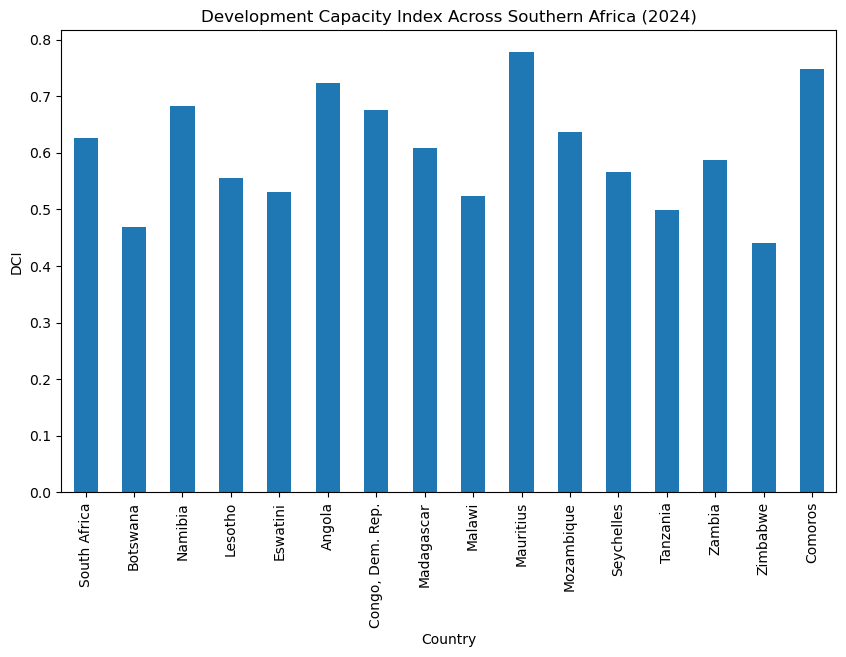

In [79]:
import matplotlib.pyplot as plt

DCI_table['2024'].plot(kind='bar', figsize=(10,6))

plt.title("Development Capacity Index Across Southern Africa (2024)")
plt.xlabel("Country")
plt.ylabel("DCI")
plt.xticks(rotation=90)

plt.show()